# Event rate reconstruction

This notebook explains how to model a process that produces
integer-valued count data, for example, from a photon source or the decay of a
radioactive element. It introduces the Poisson distribution as the
corresponding likelihood and the constraints that must be employed to model
the rate function of the underlying Poisson process.
If you are not familiar with NIFTy, please start with the notebooks [Models](0_models)
and [Inference](1_inference).

In [13]:
import jax

jax.config.update("jax_enable_x64", True)

import nifty.re as jft

import numpy as np
import jax.numpy as jnp
import jax.random as random

%matplotlib inline
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100

from functools import partial

seed = 42
rng_key = random.PRNGKey(seed)

## Poisson process

A Poisson process is a counting process with a strictly positive
rate function $\rho (x)$. Under a counting process, we can understand a
stochastic process that keeps track of all registered events in a given space
$\mathcal{S}$. The rate function $\rho (x)$ describes the rate of events in an
infinitesimal volume in $\mathcal{S}$. Furthermore, for a Poisson process, the
registered events in a region $\Omega$ are distributed by a Poisson
distribution

$$ P(n|\lambda) = \frac{\lambda^n \, e^{-\lambda}}{n!} $$

with $n \in \mathbb{N}_0$ being the number of registered events and

$$ \lambda = \int_{\Omega} dy \, \rho (y) $$

being the expected counts in the region $\Omega$. The corresponding
Hamiltonian $\mathcal{H}(n | \lambda)$ to the Poisson distribution
$P(n | \lambda)$ reads

$$ \mathcal{H}(n | \lambda) = - \text{ln} \big[ P(n | \lambda) \big] = \lambda - n \, \text{ln}(\lambda) + \text{ln}(n!) $$


## Log-normal Poisson model

The generative log-normal Poisson model first starts with a normally
distributed random field $s(x)$ drawn from a normal distribution
$\mathcal{G}(s,S)$. To ensure positivity and allow for variations over several
orders of magnitude, $s(x)$ will not directly be used as a model for the rate
function, but rather as the logarithm of the rate function scales. Consequently,
the functional relation between $\rho (x)$ and $s^x$ reads as follows

$$ s(x) = \text{ln}\bigg( \frac{\rho(x)}{\rho_0} \bigg) \iff \rho(x) = \rho_0 \, \text{e}^{s(x)}. $$

Moreover, $\rho_0$ is chosen such that it ensures
$\langle s \rangle_{(s)} = 0$.

Similar to the definition of expected counts for the Poisson process, applying
a response $R(x)$ to the rate function $\rho^x$ gives the expected count

$$ \lambda = \int_\Omega dx \, R(x) \, \rho(x) $$

in a region $\Omega$. For Poisson count observations, $R$ can, for example,
contain exposure maps, point spread functions, or masking operations.

For a set of bins $\left\{ \Omega_i \right\}_{i=1}^{N_\text{bin}}$,
the log-normal Poisson model assumes a Poissonian $\mathcal{P}(d_i|\lambda_i)$
likelihood for every single bin $i \in \left( 1, \dots, N_\text{bin}\right)$.
We can assume that these bins are different regions
$\left\{ \Omega_i \right\}_{i=1}^{N_\text{bin}}$ for which we can ask how probable it is that a certain number of
events occurred. Assuming independent noise for each bin, the joint likelihood

$$ \mathcal{P}(d|\lambda) = \prod_i \mathcal{P}(d_i|\lambda_i) = \prod_i \frac{(\lambda_i)^{d_i} \, e^{-\lambda_i}}{d_i!} $$

is just a product of all single bin likelihoods.

### Log-normal Poisson model with the correlated field

This section should be an example of how to model Poisson count data in time.
Naturally, we can extend the procedure to multiple dimensions, similar to this
example.

First, let us read the data contained in `data_poisson.txt`.

In [14]:
events = np.loadtxt("data_poisson.txt")

for k in range(15):
    print(events[k])

17.025680541992188
23.017667770385742
26.773649215698242
28.523881912231445
29.105871200561523
30.136960983276367
31.293071746826172
31.614225387573242
32.483299255371094
32.93983840942383
33.88088607788086
33.984371185302734
34.11470031738281
34.33364486694336
34.449947357177734


`events` now contains all recorded events' time stamps, but
there is still no count data. Therefore, we take all events and bin them over
the viewed interval $[0,T]$ with a resolution of `t_res`. In this analysis, we
choose the last timestamp as our $T$. Using `jnp.histogram`, we get the counts
per bin and its bin bounds. Moreover, by only setting the number of desired
bins, we get uniform bins with bin width $\Delta t$.

Now let us visualize the binned count data.

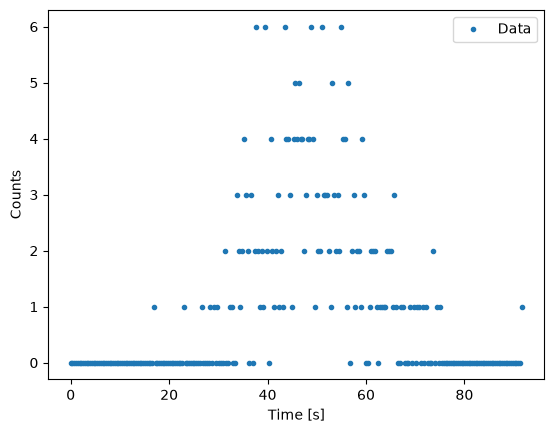

In [15]:
t_res = 2**8
T = events.max()
data, bins = np.histogram(events, t_res, (0, T))
bins = bins[:-1]

plt.xlabel("Time [s]")
plt.ylabel("Counts")
plt.plot(bins, data, ".", label="Data", color="tab:blue")
plt.legend(loc="upper right")
plt.show()

The plot shows us that roughly between 30 and 70 seconds, we
have more counts than at the beginning and end of the interval. Therefore, it
is plausible that the underlying rate function $\rho(t)$ must be higher in
this region, meaning $\rho(t)$ allows for a greater number of events.

Now let us model the rate function $\rho(t)$ itself.

The exact form of $\rho(t)$ is unavailable in a real-world scenario.
Therefore, we model the rate function $\rho(t)$ via the log-normal Poisson
model. We choose a correlated field with a non-parametric power spectrum for
the underlying Gaussian process. Since the correlated field uses the Hartley
transformation, it follows periodic boundary conditions.
To reconstruct also non-periodic signals, we make use of zero padding.
For that, we define our correlated field for twice the time interval
and then cut out the zero-padded region in the forward model.
Furthermore, we choose the `distances` of the correlated
field to coincide with the bin width of the data.
This saves us transformations between (differently binned) data and Poisson rates,
simplifying  operators or fields of the model for the expected counts.

In [32]:
# Define the correlated field to model lambda

cf_offset_dict = dict(
    offset_mean = 1,
    offset_std = (0.5, 0.1),
)

cf_ps_dict = dict(
    shape = 2 * t_res,
    distances = T / t_res,
    non_parametric_kind = "power",
    fluctuations = (0.5, 0.1),
    loglogavgslope = (-4, 0.5),
    flexibility = (1., 0.5),
    asperity = (10., 0.5)
)

cf_maker = jft.CorrelatedFieldMaker("signal_")
cf_maker.set_amplitude_total_offset(**cf_offset_dict)
cf_maker.add_fluctuations(**cf_ps_dict)
s = cf_maker.finalize()

The forward model mainly consists of the log-normal Poisson model described at the beginning.

1. We choose the correlated field's timeline to coincide with the data's
   timeline in the first half.
   The second half is the artificial zero padding region
   and must be cut out. The method `signal` in the
   forward model applies this slicing operation.
2. Next, we ensure positivity by exponentiating the resulting signal in the `exp_signal` method.
   By making it a separate method, we can easily extract $\rho(t)$ later
   if needed.
3. Lastly, we compute the expected counts from the Poisson rate.
   Recall that the log-normal Poisson model computes the expected counts per
   bin $i$ within the time interval $\left[t_i,t_{i+1} \right]$ as

   $$\lambda_i = \int_{t_i}^{t_{i+1}} d\tau \, R_i(\tau) \, e^{s(\tau)}.$$

   In our case, the response operator $R$ is the identity operator.
   As one entry of the signal field $s$ corresponds to exactly one data
   bin, we can assume that ${s(t)} = s(t_i) = s_i$. The integral simplifies to

   $$\lambda_i = e^{s_i} \, \int_{t_i}^{t_{i+1}} d\tau  = e^{s_i} \, (t_{i+1}-t_i) = e^{s_i} \, \Delta t.$$

   Thus, the `__call__` method of the forward model takes the expontiated signal
   and multiplies all array entries by the bin width.

In [35]:
# Define the forward model and instantiate

class LogNormalPoisson(jft.Model):
    def __init__(self, signal_field, res, T):
        self.s = signal_field
        self.res = res
        self.dt = T / res

        super().__init__(init = signal_field.init)

    def signal(self, x):
        return self.s(x)[:self.res]

    def exp_signal(self, x):
        return jnp.exp(self.signal(x))

    def __call__(self, x):
        return self.dt * self.exp_signal(x)

lamb = LogNormalPoisson(s, t_res, T)


To see if the chosen hyperparameters of our correlated field
prior are reasonable, let us look at some prior samples of our forward model.

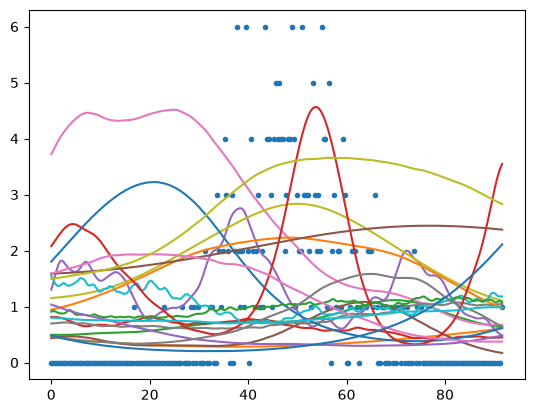

In [67]:
# Plot prior samples to see if the model can describe the data

plt.plot(bins, data, ".")
key, k1 = random.split(rng_key, 2)

for k in range(20):
    k0, k1 = random.split(k1, 2)
    plt.plot(bins, lamb(lamb.init(k0)))

The plot above displays the data count by the points, and 20
prior samples as graphs. We can see that the hyperparameters are set to
reasonable values, as the different prior samples show enough variance in
amplitude and offset to cover almost every possible data point. Furthermore,
the different realizations show that the variance on the hyperparameters
allows for a wide range of possible realizations, thus enabling the search for
the correct values of the hyperparameters.

Next, we have to define the likelihood of our inference problem.
For count data, as we are using the log-normal Poisson model, we choose a
Poissonian likelihood. `NIFTy.re` implements a Poissonian likelihood as the
class `jft.Poissonian`. The class itself needs the binned count data and
computes the Information Hamiltonian of a multivariate Poisson distribution

$$ \mathcal{H}(d|\lambda) = \sum_i \mathcal{H}(d_i|\lambda_i) = \sum_i \lambda_i - d_i \, \text{ln}(\lambda_i) + \text{ln}(d_i!) $$

up to constant terms in $\lambda_i$.

As the likelihood does not know about the model, we must amend an instance of
the model class.

In [37]:
# Define the likelihood and amend the model

lh = jft.Poissonian(data).amend(lamb)

The last part is again the inference algorithm. For an introduction on using the
`optimize_kl` function, please look at the [inference notebook](1_inference).
For visualization, we evaluate the mean and standard deviation of the
exponentiated signal $\text{e}^{s(t)}$ after each VI iteration and plot the
mean, together with a $1 \sigma$ -band, against the exact rate function
$\rho(t)$. Furthermore, the reconstructed power spectrum of the correlated
field is shown next to it.

In [40]:
# Write the callback function for plotting

def callback(samples, state):
    exp_mean, exp_std = jft.mean_and_std(tuple(lamb.exp_signal(s) for s in samples))
    ps_mean, ps_std = jft.mean_and_std(tuple(cf_maker.power_spectrum(s) for s in samples))

    fig, axs = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

    axs[0].plot(bins, exp_mean, color="tab:blue", label="Posterior Mean")
    axs[0].fill_between(bins, exp_mean - exp_std, exp_mean + exp_std, color="tab:blue", alpha=0.3)
    axs[0].legend()

    axs[1].set_xscale("log")
    axs[1].set_yscale("log")
    axs[1].plot(s.target_grids[0].harmonic_grid.mode_lengths,
                ps_mean,
                label = "Posterior Power Spectrum",
                color = "tab:blue")

We will now use the geometric Variational Inference (geoVI) algorithm that is better
in approximating non-Gaussian posteriors than Metric Gaussian Variational
Inference (MGVI),
as the posterior will generally be non-Gaussian. Let's motivate this by
looking at the joint distribution of data $d$ and the expectation value
$\lambda$ in one bin. Considering only one bin, we have a one-dimensional
Gaussian and Poisson distribution for the prior and likelihood. Additionally,
we assume a unit response in the log-normal model, meaning that
$\lambda(s)=\text{e}^s$.

$$ \mathcal{P}(s) = \mathcal{G}(s,\sigma^2) = \frac{1}{\sqrt{2\pi}\sigma} \, \text{e}^{-\frac{s^2}{2\sigma^2}}\\ \mathcal{P}(d|\lambda(s)) = \frac{\lambda^d \, \text{e}^{-\lambda}}{d!} $$

Since $\lambda$ is defined by an exponentiated normally distributed $s$, it
will follow the log-normal distribution

$$ \mathcal{P}(\lambda) = \frac{1}{\sqrt{2\pi}\sigma \, \lambda} \, \text{exp}\bigg[ -\frac{\text{ln}^2(\lambda)}{2\sigma^2} \bigg]. $$

The joint distribution of $d$ and $\lambda$ will therefore reads

$$ \mathcal{P}(d,\lambda) = \mathcal{P}(d|\lambda) \, \mathcal{P}(\lambda) \propto \lambda^{d-1} \, \text{exp}\bigg[ -\lambda -\frac{\text{ln}^2(\lambda)}{2\sigma^2} \bigg]. $$

Now, let us visualize the unnormalized posterior distribution.

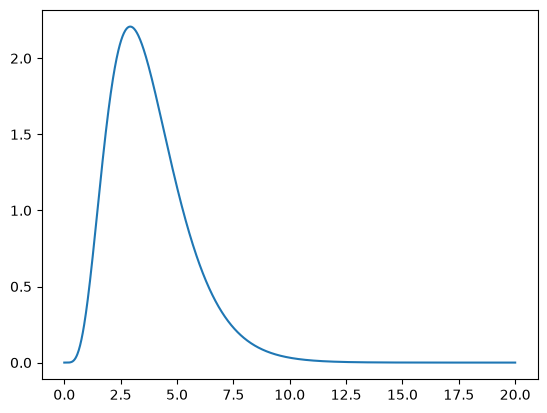

In [46]:
def joint_PDF_curve(x, d, sigma):
    return x ** (d - 1) * jnp.exp(-x - jnp.log(x) ** 2 / (2 * sigma**2))


x = jnp.linspace(0, 20, 1000)
y = joint_PDF_curve(x, 5, 1)

plt.plot(x, y)
plt.show()

As we can see, the posterior

$$ \mathcal{P}(\lambda|d) = \frac{\mathcal{P}(d,\lambda)}{\mathcal{P}(d)} \propto \lambda^{d-1} \, \text{exp}\bigg[ -\lambda -\frac{\text{ln}^2(\lambda)}{2\sigma^2} \bigg] $$

deviates from a Gaussian posterior. Therefore, using MGVI in the inference
scheme may lead to a suboptimal reconstruction. Now, let us use the geoVI
(see https://arxiv.org/abs/2105.10470) algorithm, which uses the Fisher
Information metric to construct non-Gaussian posterior distributions.

Now let us specify the `optimize_kl` arguments.


In [ ]:
# Write the arguments for the samplers and minimizers

delta = 1.e-6
key, k_i, k_o = random.split(rng_key, 3)

optimize_kl_args = dict(
    likelihood = lh,
    position_or_samples = jft.Vector(lh.init(k_i)),
    n_total_iterations = 3,
    n_samples = 5,
    key= k_o,
    draw_linear_kwargs= dict(
        cg_name=None,
        cg_kwargs=dict(absdelta=delta * jft.size(lh.domain), maxiter=300),
        ),
        nonlinearly_update_kwargs=dict(
            minimize_kwargs=dict(
                name=None,
                xtol=delta,
                cg_kwargs=dict(name=None),
                maxiter=5
            )
        ),
        kl_kwargs=dict(
            minimize_kwargs=dict(
                name=None, xtol=delta, cg_kwargs=dict(name=None), maxiter=35
            )
        ),
        sample_mode="nonlinear_resample",
        callback=callback,
    )

By setting the `sample_mode` of the `optimize_kl` to
`nonlinear_resample`, we will use the geoVI algorithm in the inference
process. Furthermore, we must now set the `nonlinearly_update_kwargs` in the
`optimize_kl`. Similar to the minimizers introduced in the notebook
`1_inference`, these set the parameters for a Newton conjugate gradient scheme
to calculate geoVI samples.

Furthermore, we can make a function call after each VI iteration by specifying
the' callback' argument. As an example, like we did here, we can repeatedly
compute plots of specific quantities during the inference.

OPTIMIZE_KL: Starting 0001
N: Iteration Limit Reached
OPTIMIZE_KL: Iteration 0001 E:+6.4071e+02
OPTIMIZE_KL: #(Nonlinear sampling steps) (3, 3, 3, 3, 3, 3, 2, 2, 3, 3)
OPTIMIZE_KL: #(KL minimization steps) 35
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     0.9±    0.26, avg:   -0.067±    0.18, #dof:    256'

OPTIMIZE_KL: Prior residual(s):
signal_asperity         :: 'reduced Chi²:     1.0±    0.64, avg:  -0.0019±     1.0, #dof:      1'
signal_flexibility      :: 'reduced Chi²:     1.4±     1.4, avg:     +1.0±    0.63, #dof:      1'
signal_fluctuations     :: 'reduced Chi²:     1.0±     1.4, avg:    -0.45±    0.89, #dof:      1'
signal_loglogavgslope   :: 'reduced Chi²:    0.87±     1.1, avg:    -0.14±    0.92, #dof:      1'
signal_spectrum         :: 'reduced Chi²:     1.0±   0.082, avg:  -0.0092±   0.036, #dof:    510'
signal_xi               :: 'reduced Chi²:     1.1±   0.091, avg:   -0.011±   0.039, #dof:    512'
signal_zeromode         :: 'reduced Chi²:     1.3±     1.9, av

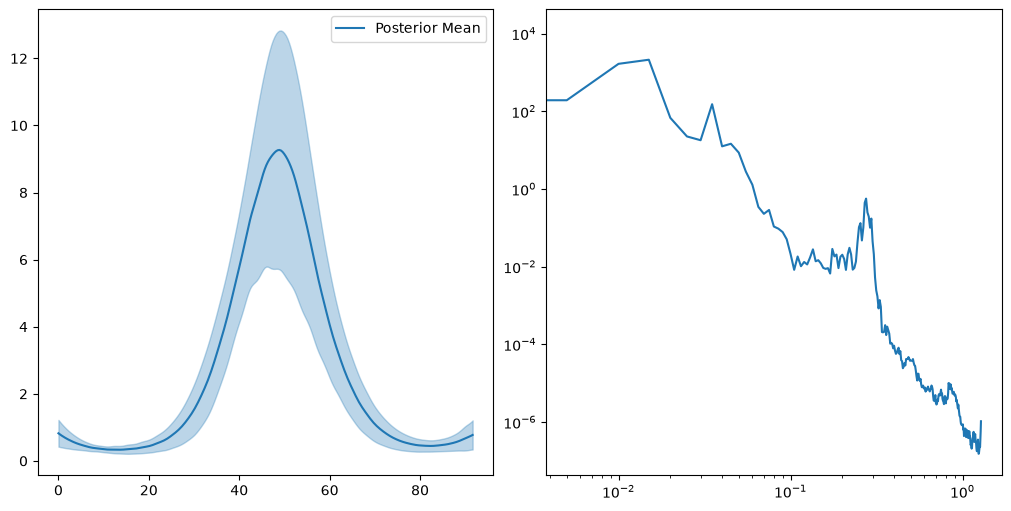

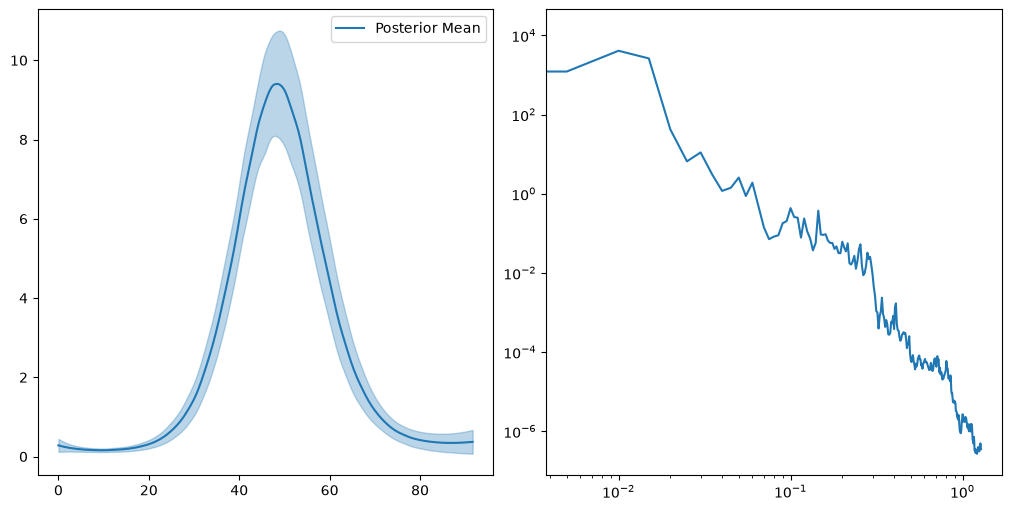

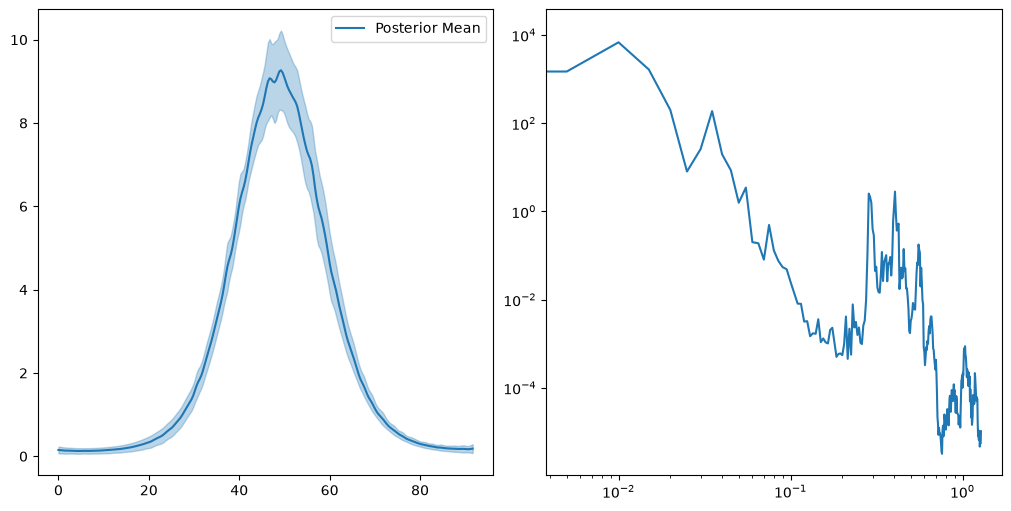

In [77]:
# Run the inference

samples, state = jft.optimize_kl(**optimize_kl_args)

## Summary

This notebook introduces how to implement the log-normal Poisson process in
`NIFTy`. It presents how to preprocess event count data for a `jft.Poissonian`
likelihood. Furthermore, it provides an example of a use case of the
correlated field and why we should use the Geometric Variational Inference
(geoVI) algorithm. The notebook also showed how to set up `optimize_kl` to use
geoVI.

## Appendix

The given data was generated by the rate function

$$ \rho(t) = A \, \text{e}^{-\frac{1}{2} \big(\frac{t-t_0}{w}\big)^2} $$

and generate data from it with the Lewis-Shedler
(see https://bookdown.org/rdpeng/timeseriesbook/simulation-and-prediction.html for a short summary on it)
algorithm to simulate an inhomogeneous process. This gives us a list of events
distributed over time.

In [24]:
def rho(t, c):
    t0 = c[0]
    w = c[1]
    A = c[2]
    return A * jnp.exp(-((t - t0) ** 2) / (2 * w**2))

In [25]:
def generate_poisson_data(key, f, f_max, T):
    t = 0
    events = []

    while t <= T:
        key, k0 = random.split(key, 2)

        u = random.uniform(k0)
        del_t = -jnp.log(u) / f_max

        events.append(t)
        t += del_t

    events = jnp.array(events)

    v = random.uniform(key, events.shape)

    p = f(events) / f_max
    mask = v <= p

    return events[mask]


rho_max = 10
T = 100
c = (50, 10, rho_max)


simulated_events = generate_poisson_data(rng_key, partial(rho, c=c), rho_max, T)